In [2]:
pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 147.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.5/794.5 kB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [transformers] [transformers]
Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install "numpy<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 142.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [2]:
import os
import glob
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import pytorch_lightning as pl
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import segmentation_models_pytorch as smp
from torchmetrics import JaccardIndex
from torchmetrics.classification import F1Score as TorchF1Score
import matplotlib.pyplot as plt
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, LearningRateMonitor
from pytorch_lightning.loggers import CSVLogger
from pathlib import Path
import warnings
import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import SegformerForSemanticSegmentation, SegformerConfig, get_cosine_schedule_with_warmup
from torch.utils.data.dataloader import default_collate

In [ ]:
def _create_overlay_image(original_image_tensor, masks_tensor, label_categories, alpha=0.5):
    """
    이미지와 마스크를 오버레이하여 PIL 이미지를 생성합니다.
    Agriculture-Vision 데이터셋에 최적화된 버전
    """
    try:
        # GPU 텐서를 CPU로 이동하고 numpy로 변환
        if original_image_tensor.is_cuda:
            original_image_tensor = original_image_tensor.cpu()
        if masks_tensor.is_cuda:
            masks_tensor = masks_tensor.cpu()
            
        image_np = original_image_tensor.detach().numpy()
        mask_np = masks_tensor.detach().numpy()
        
        # 마스크 차원 변환
        if len(mask_np.shape) == 3:
            if mask_np.shape[-1] == len(label_categories):  # (H, W, C) 형태
                mask_np = np.transpose(mask_np, (2, 0, 1))  # (C, H, W)로 변환

        # print(f"Debug - Image tensor shape: {image_np.shape}, range: [{image_np.min():.3f}, {image_np.max():.3f}]")
        # print(f"Debug - Mask tensor shape: {mask_np.shape}, range: [{mask_np.min():.3f}, {mask_np.max():.3f}]")
        
        # Agriculture-Vision 특화 이미지 전처리
        # 정규화된 이미지를 원래 이미지로 복원
        if image_np.shape[0] == 4:  # RGB+NIR인 경우
            # RGB 채널만 사용하고 정규화 해제
            rgb_tensor = image_np[:3]  # RGB 채널만 선택
            mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
            std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
            rgb_tensor = rgb_tensor * std + mean  # 정규화 해제
            rgb_tensor = np.clip(rgb_tensor, 0, 1)
            image_np = rgb_tensor
        elif image_np.shape[0] == 3:  # RGB만 있는 경우
            if image_np.min() < 0:  # 정규화된 경우
                mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
                std = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
                image_np = image_np * std + mean
                image_np = np.clip(image_np, 0, 1)
        elif image_np.shape[0] == 1:  # 그레이스케일인 경우
            image_np = np.repeat(image_np, 3, axis=0)
        else:
            print(f"Warning: Unexpected image channels: {image_np.shape[0]}, using first 3 channels")
            image_np = image_np[:3]
        
        # (C, H, W) -> (H, W, C)로 변환
        image_np = np.transpose(image_np, (1, 2, 0))
        
        # 값 범위 확인 및 조정
        if image_np.max() > 1.0:
            image_np = image_np / 255.0
        image_np = np.clip(image_np, 0, 1)
        
        # PIL 이미지로 변환
        base_img_pil = Image.fromarray((image_np * 255).astype(np.uint8)).convert("RGBA")
        
        # 마스크가 있는 경우에만 오버레이 적용
        if alpha > 0 and len(mask_np.shape) >= 2:
            # 마스크 색상 정의
            mask_colors = {
                'cloud_shadow': (255, 0, 0, int(255 * alpha)),     # 빨강
                'double_plant': (255, 255, 0, int(255 * alpha)),   # 노랑
                'planter_skip': (0, 255, 255, int(255 * alpha)),   # 시안
                'standing_water': (128, 0, 128, int(255 * alpha)), # 보라
                'waterway': (255, 165, 0, int(255 * alpha)),       # 주황
                'weed_cluster': (255, 0, 255, int(255 * alpha))    # 마젠타
            }
            
            final_img = base_img_pil.copy()
            
            # 다중 클래스 마스크 처리
            if len(mask_np.shape) == 3:  # (C, H, W)
                for i, category in enumerate(label_categories):
                    if i < mask_np.shape[0]:
                        class_mask = mask_np[i] > 0.5
                        if np.any(class_mask):
                            # 마스크 색상 생성
                            colored_mask_np = np.zeros((*class_mask.shape, 4), dtype=np.uint8)
                            color = mask_colors.get(category, (128, 128, 128, int(255 * alpha)))
                            colored_mask_np[class_mask] = color
                            
                            # 오버레이 적용
                            colored_mask_pil = Image.fromarray(colored_mask_np, 'RGBA')
                            final_img = Image.alpha_composite(final_img, colored_mask_pil)
            else:  # (H, W) 단일 마스크
                class_mask = mask_np > 0.5
                if np.any(class_mask):
                    colored_mask_np = np.zeros((*class_mask.shape, 4), dtype=np.uint8)
                    colored_mask_np[class_mask] = (0, 255, 0, int(255 * alpha))  # 기본 초록색
                    
                    colored_mask_pil = Image.fromarray(colored_mask_np, 'RGBA')
                    final_img = Image.alpha_composite(final_img, colored_mask_pil)
            
            return final_img
        else:
            return base_img_pil
        
    except Exception as e:
        print(f"Error in _create_overlay_image: {e}")
        # 에러 시 기본 이미지 반환
        try:
            if original_image_tensor.is_cuda:
                original_image_tensor = original_image_tensor.cpu()
            image_np = original_image_tensor.detach().numpy()
            
            if image_np.shape[0] >= 3:
                image_np = image_np[:3]
            elif image_np.shape[0] == 1:
                image_np = np.repeat(image_np, 3, axis=0)
            else:
                image_np = np.zeros((3, 256, 256))
                
            image_np = np.transpose(image_np, (1, 2, 0))
            image_np = np.clip(image_np, 0, 1) if image_np.max() <= 1.0 else np.clip(image_np / 255.0, 0, 1)
            
            return Image.fromarray((image_np * 255).astype(np.uint8))
        except:
            # 최후의 수단: 검은색 이미지
            return Image.fromarray(np.zeros((256, 256, 3), dtype=np.uint8))

# --- 블록 2: 데이터 관련 클래스 정의 (수정됨) ---
class AgricultureVisionDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        
        # RGB와 NIR 디렉토리 모두 정의
        self.rgb_dir = os.path.join(root_dir, split, 'images', 'rgb')
        self.nir_dir = os.path.join(root_dir, split, 'images', 'nir')
        self.labels_base_dir = os.path.join(root_dir, split, 'labels')
        self.masks_dir = os.path.join(root_dir, split, 'masks')
        self.boundaries_dir = os.path.join(root_dir, split, 'boundaries')

        # RGB 기준으로 파일명 수집
        self.image_filenames = [
            os.path.splitext(os.path.basename(p))[0]
            for p in glob.glob(os.path.join(self.rgb_dir, '*.jpg')) + glob.glob(os.path.join(self.rgb_dir, '*.png'))
        ]
        self.image_filenames.sort()

        self.label_categories = []
        if os.path.exists(self.labels_base_dir):
            self.label_categories = [d for d in os.listdir(self.labels_base_dir) if os.path.isdir(os.path.join(self.labels_base_dir, d))]
            self.label_categories.sort()

        print(f"Loaded {len(self.image_filenames)} images for {split} split using RGB+NIR (4 channels).")
        if self.label_categories:
            print(f"Detected label categories: {self.label_categories}")

    def __len__(self):
        return len(self.image_filenames)

    def __getitem__(self, idx):
        img_basename = self.image_filenames[idx]

        # RGB 이미지 로드
        rgb_path_jpg = os.path.join(self.rgb_dir, f"{img_basename}.jpg")
        rgb_path_png = os.path.join(self.rgb_dir, f"{img_basename}.png")
        
        if os.path.exists(rgb_path_jpg):
            rgb_img = np.array(Image.open(rgb_path_jpg).convert("RGB"))
        elif os.path.exists(rgb_path_png):
            rgb_img = np.array(Image.open(rgb_path_png).convert("RGB"))
        else:
            raise FileNotFoundError(f"RGB image not found for {img_basename}")
        
        # NIR 이미지 로드
        nir_path_jpg = os.path.join(self.nir_dir, f"{img_basename}.jpg")
        nir_path_png = os.path.join(self.nir_dir, f"{img_basename}.png")
        
        if os.path.exists(nir_path_jpg):
            nir_img = np.array(Image.open(nir_path_jpg).convert("L"))
        elif os.path.exists(nir_path_png):
            nir_img = np.array(Image.open(nir_path_png).convert("L"))
        else:
            # NIR이 없으면 제로 채널로 대체
            nir_img = np.zeros_like(rgb_img[:,:,0])        
        
        # 4채널로 결합 (RGB + NIR)
        img = np.concatenate([rgb_img, nir_img[:,:,np.newaxis]], axis=2)
        
        masks_list = []
        
        # label_categories만 사용 (boundaries는 제외)
        for category in self.label_categories:
            label_path = os.path.join(self.labels_base_dir, category, f"{img_basename}.png")
            if os.path.exists(label_path):
                # 중요: 마스크를 255로 나누지 않고 255인 부분만 1로 변환
                mask = np.array(Image.open(label_path).convert("L"))
                binary_mask = (mask == 255).astype(np.float32)  # 255인 부분만 1, 나머지는 0
                masks_list.append(binary_mask)
            else:
                masks_list.append(np.zeros_like(img[:,:,0], dtype=np.float32))
        
        # 마스크 스택
        masks = np.stack(masks_list, axis=-1).astype(np.float32)
        
        if self.transform:
            augmented = self.transform(image=img, mask=masks)
            img = augmented['image']
            masks = augmented['mask']
            
        return img, masks


# def get_baseline_train_transforms(image_size=(256, 256)):
#     """Simple baseline augmentation"""
#     return A.Compose([
#         A.Resize(image_size[0], image_size[1], interpolation=cv2.INTER_NEAREST),
#         A.HorizontalFlip(p=0.5),  # 기본적인 flip만
#         A.Normalize(mean=(0.485, 0.456, 0.406, 0.5), std=(0.229, 0.224, 0.225, 0.25)),
#         ToTensorV2(),
#     ])    

def get_train_transforms(image_size=(256, 256)):
    """Agriculture Vision 데이터셋 최적화 증강"""
    return A.Compose([
        # 리사이즈
        A.Resize(image_size[0], image_size[1], interpolation=cv2.INTER_NEAREST),
        
        # 기본 Geometric 증강 (농업 현실적 범위)
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        
        # 드론 촬영 현실적 변화 시뮬레이션
        A.ShiftScaleRotate(
            shift_limit=0.08,      # 드론 위치 미세 변화
            scale_limit=0.1,       # 고도 변화 (10% 이내)
            rotate_limit=5,       # 현실적인 회전 (5도 이내), 인위적인 검은 배경 최소화
            p=0.6,
            border_mode=cv2.BORDER_REFLECT_101
            # value=0,
            # mask_value=0
        ),
        
        # 농업 환경 특화 증강
        A.RandomBrightnessContrast(
            brightness_limit=0.15,  # 구름/그림자 효과
            contrast_limit=0.15,    # 대기 조건 변화
            p=0.4
        ),
        
        # 센서 노이즈 시뮬레이션 (약하게)
        A.GaussNoise(var_limit=(5, 20), p=0.25),
        
        # 4채널 특화: 일부 채널 드롭아웃 (NIR 센서 오류 시뮬레이션)
        A.ChannelDropout(
            channel_drop_range=(1, 1),  # 1개 채널만 드롭
            fill_value=0,
            p=0.1  # 낮은 확률로 적용
        ),
        
        # 작은 영역 드롭아웃 (잡음/가림 효과)
        A.CoarseDropout(
            max_holes=5,
            max_height=12,
            max_width=12,
            p=0.15,
            fill_value=0,
            mask_fill_value=0
        ),
        
        # 4채널용 정규화 (Agriculture Vision 데이터셋 통계 기반)
        A.Normalize(
            mean=[0.485, 0.456, 0.406, 0.408],  # NIR 채널 평균값 조정
            std=[0.229, 0.224, 0.225, 0.237]    # NIR 채널 표준편차 조정
        ),
        ToTensorV2(),
    ])


    
def get_val_test_transforms(image_size=(256, 256)):
    return A.Compose([
        A.Resize(image_size[0], image_size[1], interpolation=cv2.INTER_NEAREST),
        # 4채널용 normalize
        A.Normalize(mean=(0.485, 0.456, 0.406, 0.5), std=(0.229, 0.224, 0.225, 0.25)),
        ToTensorV2(),
    ])


def denormalize_4ch(tensor, mean=[0.485, 0.456, 0.406, 0.408], std=[0.229, 0.224, 0.225, 0.237]):
    """4채널 텐서 역정규화 (시각화용)"""
    import torch
    
    # tensor와 같은 디바이스에 mean, std 배치
    mean = torch.tensor(mean, device=tensor.device).view(4, 1, 1)
    std = torch.tensor(std, device=tensor.device).view(4, 1, 1)
    
    # 역정규화
    denorm_tensor = tensor * std + mean
    
    # RGB 채널만 추출해서 시각화 (0-1 범위로 클램핑)
    rgb_tensor = denorm_tensor[:3].clamp(0, 1)
    
    return rgb_tensor
    
class AgricultureVisionDataModule(pl.LightningDataModule):
    def __init__(self, config):
        super().__init__()
        # config 딕셔너리를 클래스 속성으로 저장하여 다른 메서드에서 접근 가능하게 합니다.
        self.config = config 
        
        # 각 변수를 config 딕셔너리에서 가져옵니다.
        self.root_dir = config['DATASET_ROOT_PATH']
        self.batch_size = config['BATCH_SIZE']
        self.num_workers = config['NUM_WORKERS'] # config에 'NUM_WORKERS' 키가 있는지 확인
        self.image_size = tuple(config['IMAGE_SIZE'])

        self.train_transform = get_train_transforms(self.image_size)
        self.val_test_transform = get_val_test_transforms(self.image_size)

        self.num_mask_channels = None
        self.label_categories = None # setup에서 AgricultureVisionDataset이 로드할 것임

    
    def setup(self, stage=None):
        print(f"Setting up datasets for stage: {stage}")
        print(f"Root directory: {self.root_dir}")
        
        # 각 split 디렉토리 존재 확인
        train_dir = os.path.join(self.root_dir, 'train')
        val_dir = os.path.join(self.root_dir, 'val')
        test_dir = os.path.join(self.root_dir, 'test')
        
        print(f"Train dir exists: {os.path.exists(train_dir)}")
        print(f"Val dir exists: {os.path.exists(val_dir)}")
        print(f"Test dir exists: {os.path.exists(test_dir)}")
        
        if os.path.exists(test_dir):
            test_files = os.listdir(test_dir)
            print(f"Test dir contents: {test_files[:5]}...")
    
        self.train_dataset = AgricultureVisionDataset(
            root_dir=self.root_dir, split='train', transform=self.train_transform
        )
        self.val_dataset = AgricultureVisionDataset(
            root_dir=self.root_dir, split='val', transform=self.val_test_transform
        )
        self.test_dataset = AgricultureVisionDataset(
            root_dir=self.root_dir, split='test', transform=self.val_test_transform
        )

        print(f"Train dataset size: {len(self.train_dataset)}")
        print(f"Val dataset size: {len(self.val_dataset)}")
        print(f"Test dataset size: {len(self.test_dataset)}")
        
        if len(self.test_dataset) == 0:
            print("Warning: Test dataset is empty! Using validation dataset for testing.")
            self.test_dataset = self.val_dataset
            
        if self.train_dataset:
            _, sample_masks = self.train_dataset[0]
            print(f"Sample masks shape: {sample_masks.shape}")
            
            # 마스크가 [H, W, C] 형태라면 마지막 차원이 채널 수
            if len(sample_masks.shape) == 3:
                self.num_mask_channels = sample_masks.shape[-1]
            else:
                print(f"Unexpected mask shape: {sample_masks.shape}")
                self.num_mask_channels = 6
                
            self.label_categories = self.train_dataset.label_categories
            print(f"Detected {self.num_mask_channels} mask channels. Label categories: {self.label_categories}")
        else:
            raise RuntimeError("Train dataset not initialized. Cannot determine mask channels.")



    # === 수정된 DataModule 부분 ===
    def custom_collate_fn(self, batch):
        images = [item[0] for item in batch]
        masks = [item[1] for item in batch]

        # 이미지 배치 생성
        collated_images = default_collate(images)
        # print(f"DEBUG_COLLATE: Collated images batch shape: {collated_images.shape}")

        # 마스크 처리 - 더 명확하게
        collated_masks_list = []
        for mask in masks:
            if isinstance(mask, np.ndarray):
                mask_tensor = torch.from_numpy(mask).float()
            else:
                mask_tensor = mask.float()

            # 마스크 차원 확인 및 변환
            # print(f"DEBUG_COLLATE: Individual mask shape before processing: {mask_tensor.shape}")
            
            # Albumentations ToTensorV2 사용시 이미 [C, H, W]일 가능성
            # 확실하지 않으니 조건부로 처리
            if mask_tensor.ndim == 3:
                if mask_tensor.shape[-1] == len(self.train_dataset.label_categories):  # [H, W, C]
                    mask_tensor = mask_tensor.permute(2, 0, 1)  # [C, H, W]
                # 이미 [C, H, W]라면 그대로 사용
            
            collated_masks_list.append(mask_tensor)

        collated_masks = default_collate(collated_masks_list)
        # print(f"DEBUG_COLLATE: Collated masks batch shape: {collated_masks.shape}")

        return collated_images, collated_masks

    def train_dataloader(self):
        loader = DataLoader(
            self.train_dataset, 
            batch_size=self.batch_size, 
            shuffle=True, 
            num_workers=self.num_workers,
            collate_fn=self.custom_collate_fn # 여기에 추가
        )
        print(f"Train dataloader created with {len(loader)} batches (num_workers={self.num_workers})")
        return loader

    def val_dataloader(self):
        loader = DataLoader(
            self.val_dataset, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers,
            collate_fn=self.custom_collate_fn # 여기에 추가
        )
        print(f"Val dataloader created with {len(loader)} batches (num_workers={self.num_workers})")
        return loader

    def test_dataloader(self):
        loader = DataLoader(self.test_dataset, batch_size=self.batch_size, shuffle=False, num_workers=self.num_workers)
        print(f"Test dataloader created with {len(loader)} batches")
        return loader

In [ ]:
class TverskyLoss(nn.Module):
    """
    Class-wise weighted Tversky Loss for multi-label segmentation
    Tversky Index = TP / (TP + α*FN + β*FP)
    Loss = 1 - Tversky Index
    """
    def __init__(self, alpha=0.7, beta=0.3, smooth=1e-6, class_weights=None):
        super(TverskyLoss, self).__init__()
        self.alpha = alpha  # False Negative에 대한 가중치
        self.beta = beta   # False Positive에 대한 가중치
        self.smooth = smooth
        self.class_weights = class_weights
        
    def forward(self, inputs, targets):
        # print(f"DEBUG_TVERSKY: inputs shape: {inputs.shape}, targets shape: {targets.shape}")
        
        # Sigmoid 적용하여 확률로 변환
        inputs = torch.sigmoid(inputs)
        batch_size, num_classes = inputs.shape[:2]
        
        # Class별로 Tversky Loss 계산
        total_loss = 0.0
        for class_idx in range(num_classes):
            # 해당 클래스의 입력과 타겟 추출 - contiguous() 추가!
            class_input = inputs[:, class_idx].contiguous().view(-1)
            class_target = targets[:, class_idx].contiguous().view(-1)
            
            # True Positives, False Negatives, False Positives 계산
            TP = (class_input * class_target).sum()
            FN = ((1 - class_input) * class_target).sum()
            FP = (class_input * (1 - class_target)).sum()
            
            # Tversky Index 계산
            tversky_index = (TP + self.smooth) / (TP + self.alpha * FN + self.beta * FP + self.smooth)
            class_loss = 1 - tversky_index
            
            # Class weight 적용
            if self.class_weights is not None:
                class_weight = self.class_weights[class_idx]
                class_loss = class_loss * class_weight
                
            total_loss += class_loss
        
        # 평균 계산하여 반환 (이 부분이 빠져있었습니다!)
        final_loss = total_loss / num_classes
        # print(f"DEBUG_TVERSKY: Fin loss: {final_loss.item():.4f}")
        return final_loss


class FocalLoss(nn.Module):
    """
    Class-wise weighted Focal Loss for addressing class imbalance
    FL(p_t) = -α_t * (1-p_t)^γ * log(p_t)
    """
    def __init__(self, alpha=1.0, gamma=1.0, class_weights=None, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.class_weights = class_weights
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        # print(f"DEBUG_FOCAL: inputs shape: {inputs.shape}, targets shape: {targets.shape}")
        
        batch_size, num_classes = inputs.shape[:2]
        
        # Class별로 Focal Loss 계산
        total_loss = 0.0
        for class_idx in range(num_classes):
            # 해당 클래스의 입력과 타겟 추출 - contiguous() 추가!
            class_input = inputs[:, class_idx].contiguous()
            class_target = targets[:, class_idx].contiguous()
            
            # BCE with logits
            bce_loss = F.binary_cross_entropy_with_logits(class_input, class_target, reduction='none')
            
            # p_t 계산
            p_t = torch.exp(-bce_loss)
            
            # Focal weight 계산: (1-p_t)^gamma
            focal_weight = (1 - p_t) ** self.gamma
            
            # Alpha weight 적용
            alpha_weight = self.alpha
            
            # Focal loss 계산
            class_focal_loss = alpha_weight * focal_weight * bce_loss
            
            # Class weight 적용
            if self.class_weights is not None:
                class_weight = self.class_weights[class_idx]
                class_focal_loss = class_focal_loss * class_weight
                
            if self.reduction == 'mean':
                class_focal_loss = class_focal_loss.mean()
            elif self.reduction == 'sum':
                class_focal_loss = class_focal_loss.sum()
                
            total_loss += class_focal_loss
        
        # 평균 계산 (들여쓰기 수정!)
        final_loss = total_loss / num_classes
        # print(f"DEBUG_FOCAL: Fin loss: {final_loss.item():.4f}")
        return final_loss


class CombinedTverskyFocalLoss(nn.Module):
    """
    Class-wise weighted Tversky Loss와 Focal Loss를 결합한 손실 함수
    """
    def __init__(self, tversky_weight=0.7, focal_weight=0.3,
                 tversky_alpha=0.3, tversky_beta=0.7,
                 focal_alpha=1.0, focal_gamma=2.0, class_weights=None):
        super(CombinedTverskyFocalLoss, self).__init__()
        self.tversky_weight = tversky_weight
        self.focal_weight = focal_weight
        
        self.tversky_loss = TverskyLoss(
            alpha=tversky_alpha,
            beta=tversky_beta,
            class_weights=class_weights
        )
        self.focal_loss = FocalLoss(
            alpha=focal_alpha,
            gamma=focal_gamma,
            class_weights=class_weights
        )
        
    def forward(self, inputs, targets):
        # print(f"DEBUG_COMBINED: Starting loss calculation...")
        # print(f"DEBUG_COMBINED: inputs shape: {inputs.shape}, targets shape: {targets.shape}")
        
        # print(f"DEBUG_COMBINED: Calling Tversky loss...")
        tversky = self.tversky_loss(inputs, targets)
        # print(f"DEBUG_COMBINED: Tversky loss: {tversky.item():.4f}")
        
        # print(f"DEBUG_COMBINED: Calling Focal loss...")
        focal = self.focal_loss(inputs, targets)
        # print(f"DEBUG_COMBINED: Focal loss: {focal.item():.4f}")
        
        combined_loss = self.tversky_weight * tversky + self.focal_weight * focal
        # print(f"DEBUG_COMBINED: Combined loss: {combined_loss.item():.4f}")
        
        return combined_loss

In [ ]:
class SegmentationModel(pl.LightningModule):
    def __init__(self, backbone_model_name, num_classes, label_categories, learning_rate=1e-4, pretrained=True):
        super().__init__()
        
        self.save_hyperparameters()
        self.backbone_model_name = backbone_model_name
        self.num_classes = num_classes
        self.label_categories = label_categories

        print(f"Initializing custom segmentation model with backbone: {backbone_model_name}")
        print(f"Initializing model with num_classes: {num_classes}")
        print(f"Label categories: {label_categories}")

        # === SegFormer 모델 로드 ===
        if pretrained:
            config = SegformerConfig.from_pretrained(backbone_model_name)
            config.num_labels = num_classes
            self.model = SegformerForSemanticSegmentation.from_pretrained(
                backbone_model_name,
                config=config,
                ignore_mismatched_sizes=True
            )
        else:
            config = SegformerConfig.from_pretrained(backbone_model_name)
            config.num_labels = num_classes
            self.model = SegformerForSemanticSegmentation(config)

        
        # === 4채널 입력을 위한 첫 번째 레이어 수정 (한 번만!) ===
        try:
            original_conv = self.model.segformer.encoder.patch_embeddings[0].proj
            new_conv = nn.Conv2d(
                in_channels=4,  # RGB + NIR
                out_channels=original_conv.out_channels,
                kernel_size=original_conv.kernel_size,
                stride=original_conv.stride,
                padding=original_conv.padding,
                bias=original_conv.bias is not None
            )
            
            # 가중치 복사
            with torch.no_grad():
                new_conv.weight[:, :3, :, :] = original_conv.weight
                new_conv.weight[:, 3:, :, :] = original_conv.weight[:, :1, :, :]  # NIR을 R 채널로 초기화
                if original_conv.bias is not None:
                    new_conv.bias.copy_(original_conv.bias)
            
            self.model.segformer.encoder.patch_embeddings[0].proj = new_conv
            print(f"Successfully initialized Segformer with 4 channels input")
            
        except Exception as e:
            print(f"Error during 4-channel input modification: {e}")
            raise


        # === 클래스 가중치 설정 ===
        total_train_images = 12901
        train_counts = {
            'cloud_shadow': 931,      # 7.2% 이미지에 존재
            'double_plant': 1761,     # 13.6% 이미지에 존재
            'planter_skip': 270,      # 2.1% 이미지에 존재 (가장 희귀)
            'standing_water': 815,    # 6.3% 이미지에 존재
            'waterway': 1769,         # 13.7% 이미지에 존재
            'weed_cluster': 8890      # 68.9% 이미지에 존재 (매우 흔함)
        }

        print("\n=== 클래스 분포 분석 (전체 12,901개 이미지 기준) ===")
        for category, count in train_counts.items():
            percentage = (count / total_train_images) * 100
            absence_rate = ((total_train_images - count) / total_train_images) * 100
            print(f"{category}: {count}/{total_train_images} images ({percentage:.1f}% 존재, {absence_rate:.1f}% 부재)")

        # 농업적 중요도와 희귀성을 결합한 가중치 (최종 결과를 위해 조정)
        agricultural_importance = {
            'planter_skip': 15.0,     # 극희귀 클래스 강력 부스팅 (최종 2.0 목표)
            'standing_water': 6.5,    # 희귀 + 중요 (최종 1.4 목표)
            'cloud_shadow': 5.2,      # 중간 중요도 + 희귀 (최종 1.2 목표)
            'double_plant': 3.8,      # 중요하지만 상당히 흔함 (최종 1.1 목표)
            'waterway': 3.2,          # 낮은 중요도 + 흔함 (최종 1.0 목표)
            'weed_cluster': 0.52      # dominant 클래스 억제 (최종 0.9 목표)
        }

        # raw weight 계산
        raw_weights = []
        print("\n=== 클래스 가중치 계산 (단계별) ===")
        for category in label_categories:
            count = train_counts.get(category, 1)
            presence_ratio = count / total_train_images
            inv_freq_weight = 1.0 / (presence_ratio + 1e-6)
            importance = agricultural_importance.get(category, 1.0)
            raw_weight = inv_freq_weight * importance
            raw_weights.append(raw_weight)
    
            print(f"{category}:")
            print(f"  - 존재 이미지: {count}/{total_train_images} ({presence_ratio*100:.1f}%)")
            print(f"  - 역빈도: {inv_freq_weight:.3f}")
            print(f"  - 중요도: {importance}")
            print(f"  - Raw 가중치: {raw_weight:.3f}")

        # 정규화: 평균이 1.0이 되도록
        mean_weight = sum(raw_weights) / len(raw_weights)
        print(f"\n평균 raw 가중치: {mean_weight:.3f}")

        # 최종 가중치 계산 (1.0 기준으로 조정, 범위 확장)
        class_weights = []
        print("\n=== 최종 가중치 (정규화 후) ===")
        for i, category in enumerate(label_categories):
            raw_weight = raw_weights[i]
            adjusted_weight = 1.0 + 0.15 * (raw_weight / mean_weight - 1.0)
            final_weight = max(0.8, min(adjusted_weight, 2.2))  # 범위를 2.2까지 확장
            
            class_weights.append(final_weight)
            print(f"{category}: {final_weight:.3f}")

        self.class_weights = torch.tensor(class_weights, dtype=torch.float32)

        # # === 클래스 가중치 설정 ===
        # total_train_images = 12901
        # train_counts = {
        #     'cloud_shadow': 931,      # 7.2% 이미지에 존재
        #     'double_plant': 1761,     # 13.6% 이미지에 존재
        #     'planter_skip': 270,      # 2.1% 이미지에 존재 (가장 희귀)
        #     'standing_water': 815,    # 6.3% 이미지에 존재
        #     'waterway': 1769,         # 13.7% 이미지에 존재
        #     'weed_cluster': 8890      # 68.9% 이미지에 존재 (매우 흔함)
        # }

        # print("\n=== 클래스 분포 분석 (전체 12,901개 이미지 기준) ===")
        # for category, count in train_counts.items():
        #     percentage = (count / total_train_images) * 100
        #     absence_rate = ((total_train_images - count) / total_train_images) * 100
        #     print(f"{category}: {count}/{total_train_images} images ({percentage:.1f}% 존재, {absence_rate:.1f}% 부재)")

        # # 농업적 중요도와 희귀성을 결합한 가중치
        # agricultural_importance = {
        #     'planter_skip': 3.5,      # 매우 중요 + 극히 희귀 (2.1% 이미지에만 존재)
        #     'standing_water': 2.8,    # 중요 + 희귀 (6.3% 이미지에 존재)
        #     'cloud_shadow': 2.2,      # 중간 중요도 + 희귀 (7.2% 이미지에 존재)
        #     'double_plant': 1.8,      # 중요하지만 상당히 흔함 (13.6% 이미지에 존재)
        #     'waterway': 1.3,          # 낮은 중요도 + 흔함 (13.7% 이미지에 존재)
        #     'weed_cluster': 0.4       # dominant 클래스 억제 (68.9% 이미지에 존재)
        # }
        

        # # ====== 여기서부터 교체 ======
        # # 먼저 raw weight 계산
        # raw_weights = []
        # print("\n=== 클래스 가중치 계산 (단계별) ===")
        # for category in label_categories:
        #     count = train_counts.get(category, 1)
        #     presence_ratio = count / total_train_images
        #     inv_freq_weight = 1.0 / (presence_ratio + 1e-6)
        #     importance = agricultural_importance.get(category, 1.0)
        #     raw_weight = inv_freq_weight * importance
        #     raw_weights.append(raw_weight)
            
        #     print(f"{category}:")
        #     print(f"  - 존재 이미지: {count}/{total_train_images} ({presence_ratio*100:.1f}%)")
        #     print(f"  - 역빈도: {inv_freq_weight:.3f}")
        #     print(f"  - 중요도: {importance}")
        #     print(f"  - Raw 가중치: {raw_weight:.3f}")
        
        # # 정규화: 평균이 1.0이 되도록
        # mean_weight = sum(raw_weights) / len(raw_weights)
        # print(f"\n평균 raw 가중치: {mean_weight:.3f}")
        
        # # 최종 가중치 계산 (1.0 기준으로 약하게 조정)
        # class_weights = []
        # print("\n=== 최종 가중치 (정규화 후) ===")
        # # 기존 계산 후 희귀/dominant 클래스 모두 보정
        # for i, category in enumerate(label_categories):
        #     raw_weight = raw_weights[i]
        #     adjusted_weight = 1.0 + 0.15 * (raw_weight / mean_weight - 1.0)
        #     final_weight = max(0.8, min(adjusted_weight, 1.3))
            
        #     # 최종 클래스별 특별 처리
        #     if category == 'planter_skip':
        #         final_weight = 2.0  # 극희귀 클래스 강력 부스팅
        #     elif category == 'weed_cluster':
        #         final_weight = 0.9  # dominant 클래스 약간 상향 (0.7→0.85)
            
        #     class_weights.append(final_weight)
        # self.class_weights = torch.tensor(class_weights, dtype=torch.float32)



        # === 손실 함수 ===
        self.combined_loss = CombinedTverskyFocalLoss(
            tversky_weight=0.7,     # Tversky 비중 증가
            focal_weight=0.3,       
            tversky_alpha=0.2,      # FN 페널티 증가 (recall 향상)
            tversky_beta=0.8,       
            focal_alpha=1.0,
            focal_gamma=2.5,        # hard example 집중
            class_weights=self.class_weights
        )

        # === 메트릭 ===
        self.iou_metric = JaccardIndex(task='multilabel', num_labels=num_classes, threshold=0.5)
        self.f1_metric = TorchF1Score(task='multilabel', num_labels=num_classes, threshold=0.5)

    def forward(self, x):
        """Forward pass through SegFormer model"""
        # print(f"DEBUG_FORWARD: Input shape: {x.shape}, dtype: {x.dtype}")
        
        # SegFormer forward
        outputs = self.model(pixel_values=x)
        logits = outputs.logits
        
        # print(f"DEBUG_FORWARD: Raw logits shape: {logits.shape}")
        
        # SegFormer 출력을 입력 크기로 업샘플링
        logits = F.interpolate(
            logits, 
            size=x.shape[-2:], 
            mode='bilinear', 
            align_corners=False
        )
        
        # contiguous() 호출로 메모리 레이아웃 문제 해결
        logits = logits.contiguous()
        
        # print(f"DEBUG_FORWARD: Final logits shape: {logits.shape}")
        return logits

    def shared_step(self, batch, stage):
        """Shared step for train/val/test"""
        images, masks = batch
    
        # print(f"DEBUG_SHARED_STEP: {stage} - Images: {images.shape}, Masks: {masks.shape}")
        # print(f"DEBUG_SHARED_STEP: {stage} - Images dtype: {images.dtype}, Masks dtype: {masks.dtype}")
        
        # 입력 검증
        if images.shape[1] != 4:
            raise ValueError(f"Expected 4 channels, got {images.shape[1]}")
        if masks.shape[1] != len(self.label_categories):
            raise ValueError(f"Expected {len(self.label_categories)} mask channels, got {masks.shape[1]}")
        

        try:
            # Forward pass
            logits = self.forward(images)
            # print(f"DEBUG_SHARED_STEP: {stage} - Logits shape: {logits.shape}")

            # 시각화 테스트            
            # with torch.no_grad():
            #     prob_masks = torch.sigmoid(logits)
            #     pred_masks = (prob_masks > 0.5).float()
            # visualize_batch(images, masks, pred_masks)

            # 손실 계산 직전 값 확인
            # print(f"DEBUG_SHARED_STEP: {stage} - Logits min/max: {logits.min().item():.4f}/{logits.max().item():.4f}")
            # print(f"DEBUG_SHARED_STEP: {stage} - Masks min/max: {masks.min().item():.4f}/{masks.max().item():.4f}")
            
            # 손실 계산
            loss = self.combined_loss(logits, masks)
            # print(f"DEBUG_SHARED_STEP: {stage} - Loss: {loss.item():.4f}")
            
            # 메트릭 계산
            with torch.no_grad():
                prob_masks = torch.sigmoid(logits)
                pred_masks = (prob_masks > 0.5).float()
                
                # 메트릭 계산 - int 타입으로 변환 (bincount 에러 해결)
                pred_masks_int = pred_masks.int()
                masks_int = masks.int()
                
                iou_score = self.iou_metric(pred_masks_int, masks_int)
                f1_score = self.f1_metric(pred_masks_int, masks_int)
                
            # print(f"DEBUG_SHARED_STEP: {stage} - IoU: {iou_score:.4f}, F1: {f1_score:.4f}")
            
        except Exception as e:
            print(f"ERROR_SHARED_STEP: {stage} - {e}")
            print(f"Images shape: {images.shape}, dtype: {images.dtype}")
            print(f"Masks shape: {masks.shape}, dtype: {masks.dtype}")
            if 'logits' in locals():
                print(f"Logits shape: {logits.shape}, dtype: {logits.dtype}")
            raise
        
        
        # Logging
        sync_needed = stage in ['val', 'test'] 
        self.log(f'{stage}_loss', loss, prog_bar=True, sync_dist=sync_needed)
        self.log(f'{stage}_iou', iou_score, prog_bar=True, sync_dist=sync_needed)
        self.log(f'{stage}_f1', f1_score, prog_bar=True, sync_dist=sync_needed)
        
        return {"loss": loss, "iou": iou_score, "f1": f1_score}

    def training_step(self, batch, batch_idx):
        result = self.shared_step(batch, "train")
        return result['loss']

    def validation_step(self, batch, batch_idx):
        result = self.shared_step(batch, "val")
        return result['loss']

    def test_step(self, batch, batch_idx):
        result = self.shared_step(batch, "test")
        return result['loss']
    
    def configure_optimizers(self):
        """Configure optimizer and scheduler"""
        # 차별화된 학습률 (Encoder vs Decoder)
        encoder_params = []
        decoder_params = []
        
        for name, param in self.model.named_parameters():
            if 'segformer.encoder' in name:  # Pretrained encoder
                encoder_params.append(param)
            else:  # Decoder (classification head)
                decoder_params.append(param)
        
        optimizer = torch.optim.AdamW([
            {
                'params': encoder_params, 
                'lr': self.hparams.learning_rate * 0.1,  # Encoder: 낮은 학습률
                'weight_decay': 1e-4
            },
            {
                'params': decoder_params, 
                'lr': self.hparams.learning_rate,        # Decoder: 기본 학습률
                'weight_decay': 1e-3                     # Decoder: 강한 정규화
            }
        ], betas=(0.9, 0.95))

        
        # 스케줄러도 함께 최적화
        # CosineAnnealingLR + Warmup 조합
        def lr_lambda(current_step):
            warmup_steps = 100  # 초기 100 스텝 동안 warmup
            if current_step < warmup_steps:
                return float(current_step) / float(max(1, warmup_steps))
            return 1.0
        
        warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, 
            T_max=30,      # 30 에포크
            eta_min=1e-7   # 최소 학습률
        )
        
        # Sequential scheduler (Warmup → CosineAnnealing)
        scheduler = torch.optim.lr_scheduler.SequentialLR(
            optimizer,
            schedulers=[warmup_scheduler, cosine_scheduler],
            milestones=[100]  # 100 스텝 후 cosine으로 전환
        )

        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",  # step 단위 업데이트 권장
                "frequency": 1,
            },
        }    
            
    def on_train_epoch_end(self):
        pass

    def on_validation_epoch_end(self):
        pass

    def on_test_epoch_end(self):
        pass

def create_directories(paths):
    """필요한 디렉터리들을 생성합니다."""
    for path in paths:
        Path(path).mkdir(parents=True, exist_ok=True)
        print(f"Directory ensured: {path}")

def validate_dataset_path(dataset_path):
    """데이터셋 경로가 유효한지 확인합니다."""
    if not os.path.exists(dataset_path):
        raise FileNotFoundError(f"Dataset path does not exist: {dataset_path}")
    
    expected_dirs = ['train', 'val']
    missing_dirs = []
    for dir_name in expected_dirs:
        dir_path = os.path.join(dataset_path, dir_name)
        if not os.path.exists(dir_path):
            missing_dirs.append(dir_name)
    
    if missing_dirs:
        print(f"Warning: Expected directories not found: {missing_dirs}")


In [ ]:
def setup_callbacks(checkpoint_dir, monitor_metric='val_iou'):
    """학습 콜백들을 설정합니다."""
    callbacks = []
    
    checkpoint_callback = ModelCheckpoint(
        monitor=monitor_metric,
        mode='max',
        save_top_k=3,  
        save_last=True,  
        filename='best_model-{epoch:02d}-{val_iou:.4f}',
        dirpath=checkpoint_dir
        # verbose=True
    )
    callbacks.append(checkpoint_callback)
    
    # early_stopping_callback = EarlyStopping(
    #     monitor=monitor_metric,
    #     mode='max',
    #     patience=7, 
    #     # verbose=True,
    #     strict=False  
    # )
    # callbacks.append(early_stopping_callback)
    
    lr_monitor = LearningRateMonitor(logging_interval='step')
    callbacks.append(lr_monitor)
    
    return callbacks, checkpoint_callback

def visualize_test_results(model_to_viz, data_module_to_viz, num_samples=5, save_path=None):
    """테스트 결과를 시각화합니다."""
    print("\n--- Starting Visualization ---")
    model_to_viz.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_to_viz.to(device)

    # 데이터로더 재설정
    data_module_to_viz.setup('test')
    
    # 여러 데이터로더 옵션을 시도
    test_dataloader = None
    dataloader_source = ""
    
    try:
        test_dataloader = data_module_to_viz.test_dataloader()
        dataloader_source = "test"
        print(f"Visualization: Test dataloader created with {len(test_dataloader)} batches")
        
        # 실제로 데이터가 있는지 확인
        sample_count = 0
        for batch in test_dataloader:
            if len(batch) >= 2 and len(batch[0]) > 0:
                sample_count += len(batch[0])
                break
            
        if sample_count == 0:
            raise ValueError("Test dataloader has no valid samples")
            
    except Exception as e:
        print(f"Visualization: Test dataloader failed ({e}). Trying validation dataloader.")
        try:
            data_module_to_viz.setup('validate')
            test_dataloader = data_module_to_viz.val_dataloader()
            dataloader_source = "validation"
            print(f"Visualization: Validation dataloader created with {len(test_dataloader)} batches")
            
            sample_count = 0
            for batch in test_dataloader:
                if len(batch) >= 2 and len(batch[0]) > 0:
                    sample_count += len(batch[0])
                    break
                    
            if sample_count == 0:
                raise ValueError("Validation dataloader has no valid samples")
                
        except Exception as e2:
            print(f"Visualization: All dataloaders failed. Cannot proceed. Error: {e2}")
            return

    if test_dataloader is None:
        print("Visualization: No valid dataloader found. Skipping.")
        return

    # 여러 배치를 시도하여 유효한 데이터 찾기
    images_list = []
    masks_list = []
    samples_collected = 0
    max_batches_to_try = min(5, len(test_dataloader))
    
    print(f"Visualization: Collecting samples from {dataloader_source} dataloader...")
    
    for batch_idx, batch in enumerate(test_dataloader):
        if batch_idx >= max_batches_to_try:
            break
            
        try:
            if not isinstance(batch, (list, tuple)) or len(batch) < 2:
                print(f"Batch {batch_idx}: Invalid batch structure")
                continue
                
            images, masks = batch[0], batch[1]
            
            if not isinstance(images, torch.Tensor) or not isinstance(masks, torch.Tensor):
                print(f"Batch {batch_idx}: Invalid tensor types")
                continue
                
            if images.numel() == 0 or masks.numel() == 0:
                print(f"Batch {batch_idx}: Empty tensors")
                continue
                
            if images.shape[0] == 0 or masks.shape[0] == 0:
                print(f"Batch {batch_idx}: Zero batch size")
                continue
            
            batch_size = images.shape[0]
            samples_to_take = min(batch_size, num_samples - samples_collected)
            
            if samples_to_take > 0:
                images_list.append(images[:samples_to_take])
                masks_list.append(masks[:samples_to_take])
                samples_collected += samples_to_take
                print(f"Batch {batch_idx}: Collected {samples_to_take} samples (total: {samples_collected})")
                
            if samples_collected >= num_samples:
                break
                
        except Exception as e:
            print(f"Batch {batch_idx}: Error processing batch - {e}")
            continue

    if not images_list or samples_collected == 0:
        print("Visualization: No valid samples could be collected.")
        return

    # 텐서 결합
    try:
        images = torch.cat(images_list, dim=0)
        masks = torch.cat(masks_list, dim=0)
        print(f"Visualization: Combined tensors. Images: {images.shape}, Masks: {masks.shape}")
    except Exception as e:
        print(f"Visualization: Error combining tensors: {e}")
        return

    # GPU로 이동
    images = images.to(device)
    masks = masks.to(device)

    # 모델 예측
    try:
        with torch.no_grad():
            logits = model_to_viz(images)
            pred_masks = (torch.sigmoid(logits) > 0.5).float()
        print("Visualization: Model prediction completed.")
    except Exception as e:
        print(f"Visualization: Error during model prediction: {e}")
        return

    # 시각화할 샘플 수 결정
    num_to_show = min(num_samples, images.shape[0])
    print(f"Visualization: Displaying {num_to_show} samples from {dataloader_source} data")

    # 시각화
    try:
        fig = plt.figure(figsize=(15, num_to_show * 5))
        plt.suptitle(f"Results from {dataloader_source.title()} Data: Original vs. Ground Truth vs. Prediction", fontsize=16)

        for i in range(num_to_show):
            print(f"Processing sample {i+1}...")
            
            # 원본 이미지
            ax = plt.subplot(num_to_show, 3, i * 3 + 1)
            try:
                original_img_pil = _create_overlay_image(
                    images[i], torch.zeros_like(masks[i]),
                    model_to_viz.label_categories, alpha=0
                )
                ax.imshow(original_img_pil)
                ax.set_title(f"Original Image {i+1}")
            except Exception as e:
                print(f"Error creating original image {i+1}: {e}")
                ax.text(0.5, 0.5, f'Error: {str(e)[:30]}...', transform=ax.transAxes, ha='center')
                ax.set_title(f"Original Image {i+1} (Error)")
            ax.axis('off')

            # Ground Truth
            ax = plt.subplot(num_to_show, 3, i * 3 + 2)
            try:
                gt_overlay_img = _create_overlay_image(
                    images[i], masks[i], model_to_viz.label_categories
                )
                ax.imshow(gt_overlay_img)
                ax.set_title(f"Ground Truth {i+1}")
            except Exception as e:
                print(f"Error creating ground truth image {i+1}: {e}")
                ax.text(0.5, 0.5, f'Error: {str(e)[:30]}...', transform=ax.transAxes, ha='center')
                ax.set_title(f"Ground Truth {i+1} (Error)")
            ax.axis('off')

            # Prediction
            ax = plt.subplot(num_to_show, 3, i * 3 + 3)
            try:
                pred_overlay_img = _create_overlay_image(
                    images[i], pred_masks[i], model_to_viz.label_categories
                )
                ax.imshow(pred_overlay_img)
                ax.set_title(f"Prediction {i+1}")
            except Exception as e:
                print(f"Error creating prediction image {i+1}: {e}")
                ax.text(0.5, 0.5, f'Error: {str(e)[:30]}...', transform=ax.transAxes, ha='center')
                ax.set_title(f"Prediction {i+1} (Error)")
            ax.axis('off')
        
        # 범례 추가
        colors = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan', 'orange', 'purple']
        legend_elements = []
        for i, category in enumerate(model_to_viz.label_categories):
            legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=colors[i % len(colors)], 
                                            label=category.replace('_', ' ').title()))

        if legend_elements:
            fig.legend(handles=legend_elements, loc='center', bbox_to_anchor=(0.5, 0.02), 
                    ncol=min(3, len(legend_elements)), fontsize=10)
        
        plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # 범례 공간 확보        
        
        # 저장 경로 확인 및 저장
        if save_path:
            try:
                import os
                # 디렉토리 생성
                save_dir = os.path.dirname(save_path) if os.path.dirname(save_path) else '.'
                os.makedirs(save_dir, exist_ok=True)
                
                plt.savefig(save_path, dpi=300, bbox_inches='tight')
                print(f"Visualization saved to: {save_path}")
            except Exception as e:
                print(f"Error saving visualization: {e}")
                # 현재 디렉토리에 저장 시도
                fallback_path = "visualization_result.png"
                try:
                    plt.savefig(fallback_path, dpi=300, bbox_inches='tight')
                    print(f"Visualization saved to fallback location: {fallback_path}")
                except Exception as e2:
                    print(f"Failed to save even to fallback location: {e2}")

        plt.show()
        print(f"Successfully displayed {num_to_show} samples from {dataloader_source} data.")
        
    except Exception as e:
        print(f"Visualization: Error during plotting: {e}")
        import traceback
        traceback.print_exc()
        return
        
    print("--- Visualization Complete ---")

def load_and_test_model(checkpoint_path, data_module, trainer, config):
    """체크포인트에서 모델을 로드하고 테스트합니다."""
    try:
        print(f"Loading model from: {checkpoint_path}")
        
        loaded_model = SegmentationModel.load_from_checkpoint(
            checkpoint_path
        )
        
        # 데이터로더 확인 및 테스트
        try:
            # test 데이터셋 존재 확인
            data_module.setup('test')
            test_dataloader = data_module.test_dataloader()
            
            # 테스트 데이터가 실제로 있는지 확인
            has_test_data = False
            try:
                test_iter = iter(test_dataloader)
                test_batch = next(test_iter)
                if len(test_batch) >= 2 and len(test_batch[0]) > 0:
                    has_test_data = True
                    print(f"Test dataset found with {len(test_dataloader)} batches")
            except (StopIteration, RuntimeError):
                has_test_data = False
            
            if has_test_data:
                print("Running test on test dataset...")
                test_results = trainer.test(loaded_model, data_module)
            else:
                print("Test dataloader is empty or invalid, using validation data for testing.")
                data_module.setup('validate')
                print("Running validation as test...")
                test_results = trainer.validate(loaded_model, data_module)
                
        except Exception as test_error:
            print(f"Test dataloader error: {test_error}")
            print("Falling back to validation data for testing.")
            try:
                data_module.setup('validate')
                test_results = trainer.validate(loaded_model, data_module)
            except Exception as val_error:
                print(f"Validation also failed: {val_error}")
                test_results = None
        
        return loaded_model, test_results
        
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

Directory ensured: tb_logs
Directory ensured: ./segformer_checkpoints_a100
Directory ensured: ./results_a100
Using device: cuda
CUDA device: NVIDIA A100-SXM4-80GB
CUDA memory: 79.2 GB

--- 데이터 모듈 초기화 ---
Setting up datasets for stage: None
Root directory: Agriculture-Vision
Train dir exists: True
Val dir exists: True
Test dir exists: True
Test dir contents: ['boundaries', 'images', 'masks']...
Loaded 12901 images for train split using RGB+NIR (4 channels).
Detected label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']
Loaded 4431 images for val split using RGB+NIR (4 channels).
Detected label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']
Loaded 3729 images for test split using RGB+NIR (4 channels).
Train dataset size: 12901
Val dataset size: 4431
Test dataset size: 3729
Sample masks shape: torch.Size([256, 256, 6])
Detected 6 mask channels. Label categories: ['cloud_s

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([6]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([6, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Successfully initialized Segformer with 4 channels input

=== 클래스 분포 분석 (전체 12,901개 이미지 기준) ===
cloud_shadow: 931/12901 images (7.2% 존재, 92.8% 부재)
double_plant: 1761/12901 images (13.7% 존재, 86.3% 부재)
planter_skip: 270/12901 images (2.1% 존재, 97.9% 부재)
standing_water: 815/12901 images (6.3% 존재, 93.7% 부재)
waterway: 1769/12901 images (13.7% 존재, 86.3% 부재)
weed_cluster: 8890/12901 images (68.9% 존재, 31.1% 부재)

=== 클래스 가중치 계산 (단계별) ===
cloud_shadow:
  - 존재 이미지: 931/12901 (7.2%)
  - 역빈도: 13.857
  - 중요도: 2.2
  - Raw 가중치: 30.485
double_plant:
  - 존재 이미지: 1761/12901 (13.7%)
  - 역빈도: 7.326
  - 중요도: 1.8
  - Raw 가중치: 13.187
planter_skip:
  - 존재 이미지: 270/12901 (2.1%)
  - 역빈도: 47.779
  - 중요도: 3.5
  - Raw 가중치: 167.227
standing_water:
  - 존재 이미지: 815/12901 (6.3%)
  - 역빈도: 15.829
  - 중요도: 2.8
  - Raw 가중치: 44.322
waterway:
  - 존재 이미지: 1769/12901 (13.7%)
  - 역빈도: 7.293
  - 중요도: 1.3
  - Raw 가중치: 9.481
weed_cluster:
  - 존재 이미지: 8890/12901 (68.9%)
  - 역빈도: 1.451
  - 중요도: 0.4
  - Raw 가중치: 0.580

평균 raw 가중치: 44.

Restoring states from the checkpoint path at ./segformer_checkpoints_a100/last.ckpt


Sample masks shape: torch.Size([256, 256, 6])
Detected 6 mask channels. Label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']


...

--- 결과 시각화 ---

--- Starting Visualization ---
Setting up datasets for stage: test
Root directory: Agriculture-Vision
Train dir exists: True
Val dir exists: True
Test dir exists: True
Test dir contents: ['boundaries', 'images', 'masks']...
Loaded 12901 images for train split using RGB+NIR (4 channels).
Detected label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']
Loaded 4431 images for val split using RGB+NIR (4 channels).
Detected label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']
Loaded 3729 images for test split using RGB+NIR (4 channels).
Train dataset size: 12901
Val dataset size: 4431
Test dataset size: 3729
Sample masks shape: torch.Size([256, 256, 6])
Detected 6 mask channels. Label categories: ['cloud_shadow', 'double_plant', 'planter_skip', 'standing_water', 'waterway', 'weed_cluster']
Test dataloader created with 59 batches
Visualization: Test dataloader 

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a7e7444a0e0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1646, in _shutdown_workers
    if w.is_alive():
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a7e7444a0e0>
Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
    self._shutdown_workers()
  File "/home/zeus/miniconda3/envs/cl

Visualization: Collecting samples from validation dataloader...
Batch 0: Collected 5 samples (total: 5)
Visualization: Combined tensors. Images: torch.Size([5, 4, 256, 256]), Masks: torch.Size([5, 6, 256, 256])
Visualization: Model prediction completed.
Visualization: Displaying 5 samples from validation data
Processing sample 1...


/tmp/ipykernel_2813/4127324492.py:83: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  colored_mask_pil = Image.fromarray(colored_mask_np, 'RGBA')


Processing sample 2...
Processing sample 3...
Processing sample 4...
Processing sample 5...
Visualization saved to: ./results_a100/test_results_nvidia/segformer-b0-finetuned-ade-512-512.png


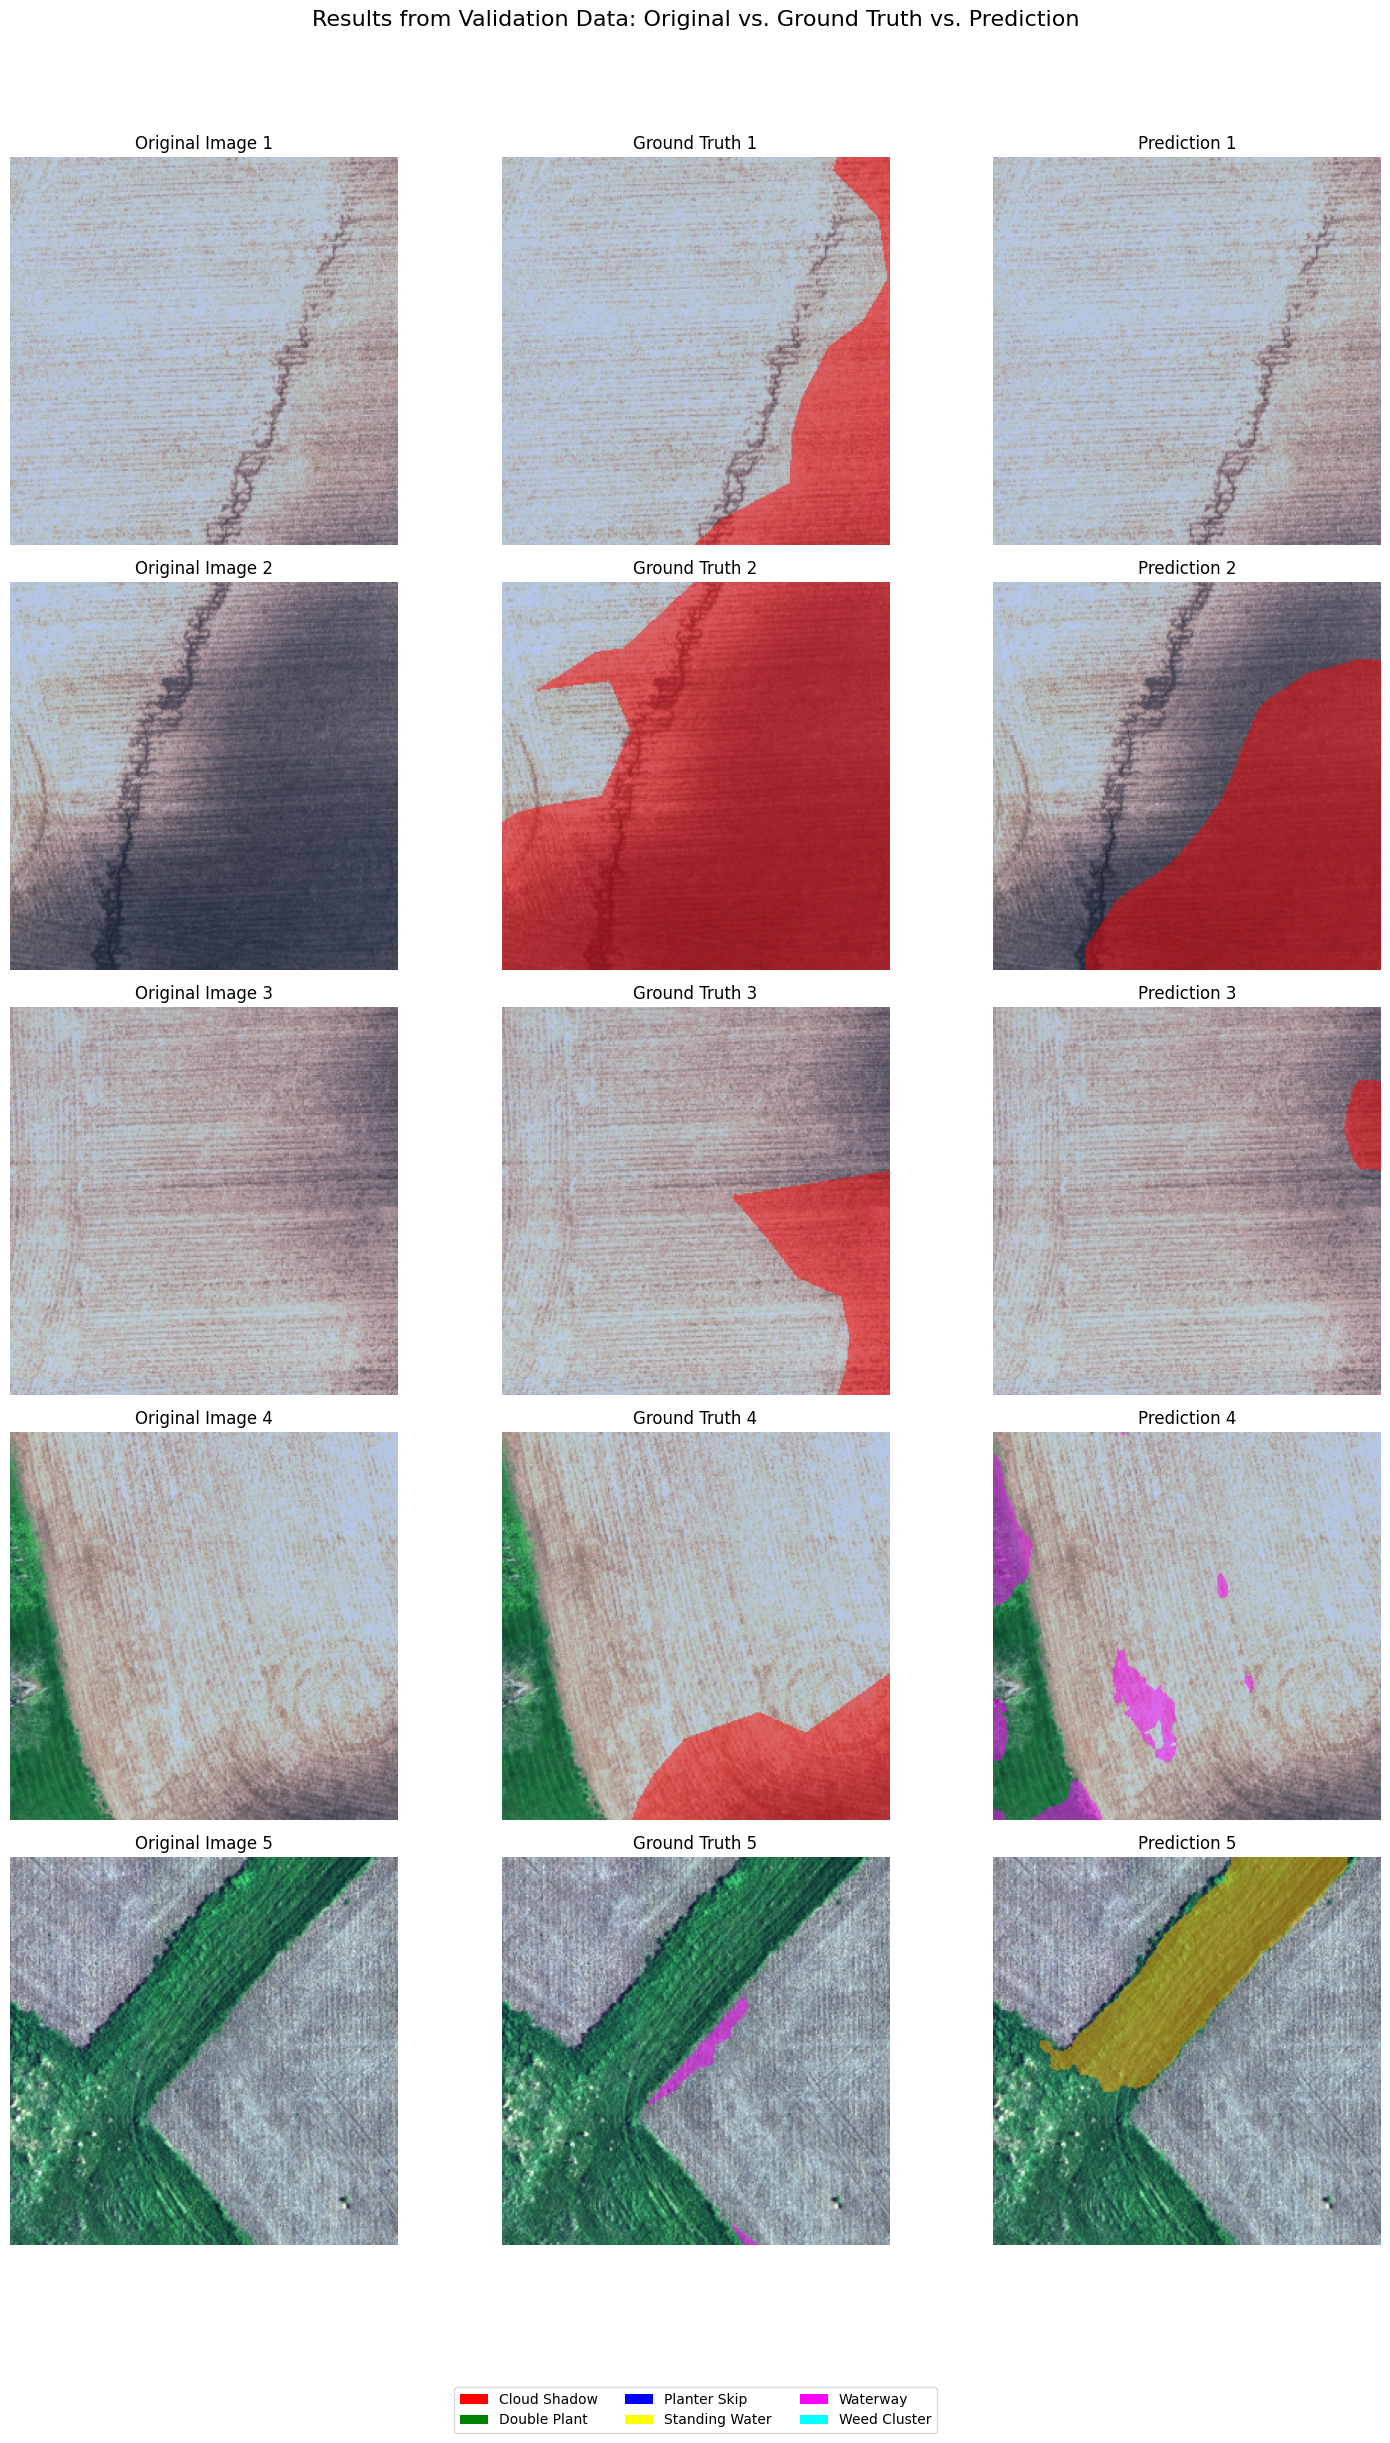

Successfully displayed 5 samples from validation data.
--- Visualization Complete ---

Best model saved at: /teamspace/studios/this_studio/segformer_checkpoints_a100/best_model-epoch=15-val_iou=0.1124.ckpt
Visualization saved at: ./results_a100/test_results_nvidia/segformer-b0-finetuned-ade-512-512.png
TensorBoard logs saved at: tb_logs
--- 모든 작업 완료 ---


In [14]:

def main():
    """메인 실행 함수"""
    # config = {
    #     'DATASET_ROOT_PATH': 'Agriculture-Vision',
    #     'BATCH_SIZE': 8,  # T4 VRAM, But SegFormer가 메모리 많이써 16 사용. 근데 워커 쓰니 4*8로 변경
    #     'NUM_WORKERS': 4,  # CPU 코어 활용을 위해 워커 수 4로 증대 (환경에 따라 8 등 조정)
    #     'PIN_MEMORY': True,     # GPU 전송 가속화 (추가하면 더 좋음)
    #     'MAX_EPOCHS': 10,  # CosineAnnealingLR 스케줄러의 T_max=30에 맞춰 에포크 조정 (선택 사항)
    #     'IMAGE_SIZE': (256, 256),
    #     'LOG_DIR': 'tb_logs',
    #     'CHECKPOINT_DIR': './segformer_checkpoints_2',
    #     'RESULTS_DIR': './results',
    #     'LEARNING_RATE': 1e-4,
    #     'BACKBONE_MODEL': 'nvidia/segformer-b0-finetuned-ade-512-512'  # Segformer 모델명으로 변경
    # }   
    config = {
        'DATASET_ROOT_PATH': 'Agriculture-Vision',
        'BATCH_SIZE': 64,  # A100 80GB 기준 (40GB면 24로 조정)
        'NUM_WORKERS': 12,  # A100 환경은 보통 더 많은 CPU 코어 제공
        'PIN_MEMORY': True,
        'MAX_EPOCHS': 30,  # 원래 계획대로 30에폭
        'IMAGE_SIZE': (256, 256),  # 더 큰 해상도로 성능 향상 (메모리 여유 있으니)
        'LOG_DIR': 'tb_logs',
        'CHECKPOINT_DIR': './segformer_checkpoints_a100',
        'RESULTS_DIR': './results_a100',
        'LEARNING_RATE': 3e-4,  # 배치 사이즈 증가에 따른 학습률 조정
        'BACKBONE_MODEL': 'nvidia/segformer-b0-finetuned-ade-512-512'
    }

    # 디렉터리 생성
    directories = [config['LOG_DIR'], config['CHECKPOINT_DIR'], config['RESULTS_DIR']]
    create_directories(directories)
    
    # 데이터셋 경로 검증
    try:
        validate_dataset_path(config['DATASET_ROOT_PATH'])
    except FileNotFoundError as e:
        print(f"Error: {e}")
        print("Please update DATASET_ROOT_PATH to the correct path.")
        return
    
    # 장치 정보 출력
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    if torch.cuda.is_available():
        print(f"CUDA device: {torch.cuda.get_device_name()}")
        print(f"CUDA memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print()
    
    try:
        # 데이터 모듈 초기화
        print("--- 데이터 모듈 초기화 ---")
        data_module = AgricultureVisionDataModule(
            config # <--- 여기만 config 딕셔너리 자체를 인자로 전달합니다.
        )
        data_module.setup()
        
        print(f"Dataset loaded successfully!")
        print(f"Number of mask channels: {data_module.num_mask_channels}")
        print(f"Label categories: {data_module.label_categories}")
        print(f"Number of classes: {data_module.num_mask_channels}")
        print()

        model = SegmentationModel(
            num_classes=data_module.num_mask_channels,
            label_categories=data_module.label_categories,
            backbone_model_name=config['BACKBONE_MODEL'],
            pretrained=True,
            learning_rate=config['LEARNING_RATE']
            # ignore_mismatched_sizes=False
        )
        
        # 모델 정보 출력
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Total parameters: {total_params:,}")
        print(f"Trainable parameters: {trainable_params:,}")
        print()

        # 콜백 및 로거 설정
        callbacks, checkpoint_callback = setup_callbacks(config['CHECKPOINT_DIR'])
        logger = CSVLogger(
            save_dir="logs",
            name="segformer_experiment"
        )

        trainer = pl.Trainer(
            default_root_dir="./segformer_logs/",
            max_epochs=config['MAX_EPOCHS'],
            accelerator="gpu" if torch.cuda.is_available() else "cpu",
            devices=1,
            callbacks=callbacks,
            logger=logger,
            log_every_n_steps=10,
            precision='16-mixed',
            accumulate_grad_batches=4,
            gradient_clip_val=1.0,
            val_check_interval=0.25,          # 🔹 8 for 30
            num_sanity_val_steps=1            # sanity check 최소화로 학습 시간 단축
        )

        # 학습 시작
        print("--- 학습 시작 ---")
        latest_checkpoint = None
        # 체크포인트 디렉토리가 존재하는지 확인
        if os.path.exists(config['CHECKPOINT_DIR']):
            # '.ckpt' 확장자를 가진 모든 체크포인트 파일 검색
            checkpoints = glob.glob(os.path.join(config['CHECKPOINT_DIR'], '*.ckpt'))
            if checkpoints:
                # 가장 최근에 수정된 체크포인트 파일 찾기
                latest_checkpoint = max(checkpoints, key=os.path.getmtime)
                print(f"Resuming from latest checkpoint: {latest_checkpoint}")
            else:
                print("No existing checkpoints found. Starting training from scratch.")
        
        # trainer.fit 호출 시 ckpt_path 인자를 통해 학습 재개
        trainer.fit(model, datamodule=data_module, ckpt_path=latest_checkpoint)
        print("--- 학습 완료 ---")
        print()

        # 최적 모델로 테스트
        print("--- 최적 모델 테스트 ---")
        best_model_path = checkpoint_callback.best_model_path
        
        if best_model_path:
            loaded_model, test_results = load_and_test_model(
                best_model_path, data_module, trainer, config
            )
            
            if loaded_model is not None:
                # 결과 시각화
                print("--- 결과 시각화 ---")
                visualization_path = os.path.join(
                    config['RESULTS_DIR'], 
                    f"test_results_{config['BACKBONE_MODEL']}.png"
                )
                visualize_test_results(
                    loaded_model, data_module, 
                    num_samples=5, save_path=visualization_path
                )
                
                print(f"\nBest model saved at: {best_model_path}")
                print(f"Visualization saved at: {visualization_path}")
                print(f"TensorBoard logs saved at: {config['LOG_DIR']}")
        else:
            print("No best model checkpoint found.")
            
    except Exception as e:
        print(f"An error occurred during training: {str(e)}")
        import traceback
        traceback.print_exc()
        return
    
    print("--- 모든 작업 완료 ---")

if __name__ == '__main__':
    # 경고 메시지 필터링 (선택사항)
    warnings.filterwarnings('ignore', category=UserWarning)
    
    main()

In [ ]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
from collections import Counter

root = "/Users/temp/Downloads/strawberry/Agriculture-Vision"
label_classes = ["cloud_shadow", "double_plant", "planter_skip", "standing_water", "waterway", "weed_cluster"]

mask_colors = {
    'cloud_shadow': (255, 0, 0, 128),
    'double_plant': (255, 255, 0, 128),
    'planter_skip': (0, 255, 255, 128),
    'standing_water': (128, 0, 128, 128),
    'waterway': (255, 165, 0, 128),
    'weed_cluster': (255, 0, 255, 128)
}
mask_colors_rgb = {k: np.array(v[:3]) / 255 for k, v in mask_colors.items()}

def load_rgb_image(split, filename):
    rgb_dir = os.path.join(root, split, "images", "rgb")
    base_name = os.path.splitext(filename)[0]
    for ext in [".jpg", ".png", ".tif"]:
        rgb_path = os.path.join(rgb_dir, base_name + ext)
        if os.path.exists(rgb_path):
            return cv2.cvtColor(cv2.imread(rgb_path), cv2.COLOR_BGR2RGB)
    return None

def _create_overlay_image_masked(rgb_img, mask_dir, label_dir, filename, label_classes, alpha=0.5):
    base = rgb_img.copy()
    mask_path = os.path.join(mask_dir, filename)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return base

    mask_bool = (mask == 255)
    overlay = np.zeros_like(base)

    for i, cls in enumerate(label_classes):
        label_path = os.path.join(label_dir, cls, filename)
        if not os.path.exists(label_path):
            continue
        label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
        if label is None:
            continue
        label_mask = (label == 255) & mask_bool

        color = np.array(mask_colors[cls][:3])
        overlay[label_mask] = color.astype(np.uint8)

    blended = (base * (1 - alpha) + overlay * alpha).astype(np.uint8)
    return blended

def _create_prediction_overlay(rgb_img, pred_mask, mask_path, label_categories, alpha=0.5):
    base = rgb_img.copy()
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return base, []

    mask_highlight = (mask == 255)
    mask_color = np.array([0, 255, 128], dtype=np.uint8)
    base[mask_highlight] = (base[mask_highlight] * 0.5 + mask_color * 0.5).astype(np.uint8)

    overlay = np.zeros_like(base)
    pred_mask = pred_mask.cpu().numpy()
    detected_classes = []

    # for i in range(pred_mask.shape[0]):
    #     if pred_mask[i].max() == 0:
    #         continue

    #     resized_pred = cv2.resize(pred_mask[i], (base.shape[1], base.shape[0]), interpolation=cv2.INTER_LINEAR)
    #     binary = (resized_pred >= 0.5) & (mask == 255)

    #     if not np.any(binary):
    #         continue

    #     color = np.array(mask_colors[label_categories[i]][:3])
    #     overlay[binary] = color.astype(np.uint8)
    #     detected_classes.append(i)

    for i in range(pred_mask.shape[0]):
        if pred_mask[i].max() == 0:
            continue

        resized_pred = cv2.resize(pred_mask[i], (base.shape[1], base.shape[0]), interpolation=cv2.INTER_LINEAR)
        binary = (resized_pred >= 0.5) & (mask == 255)

        if not np.any(binary):
            continue

        # ▶ 최소 면적 필터링
        binary_uint8 = binary.astype(np.uint8)
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary_uint8, connectivity=8)
        min_area = 20  # 픽셀 수 기준 (필요시 조정)

        filtered_binary = np.zeros_like(binary, dtype=bool)
        for j in range(1, num_labels):  # 0은 배경
            if stats[j, cv2.CC_STAT_AREA] >= min_area:
                filtered_binary |= (labels == j)

        if not np.any(filtered_binary):
            continue

        color = np.array(mask_colors[label_categories[i]][:3])
        overlay[filtered_binary] = color.astype(np.uint8)
        detected_classes.append(i)


    blended = (base * (1 - alpha) + overlay * alpha).astype(np.uint8)
    return blended, detected_classes

def show_test_result_with_model(split, filename, model, label_classes):
    filename = os.path.splitext(filename)[0] + ".png"

    rgb = load_rgb_image(split, filename)
    if rgb is None:
        print(f"원본 이미지 없음: {filename}")
        return

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f"{split.upper()} — {filename}", fontsize=14)

    axs[0].imshow(rgb)
    axs[0].set_title("Original")
    axs[0].axis('off')

    mask_dir = os.path.join(root, split, "masks")
    label_dir = os.path.join(root, split, "labels")
    overlay_gt = _create_overlay_image_masked(rgb.copy(), mask_dir, label_dir, filename, label_classes)
    axs[1].imshow(overlay_gt)
    axs[1].set_title("GT + Mask Overlay")
    axs[1].axis('off')

    gt_detected_classes = []
    for i, cls in enumerate(label_classes):
        label_path = os.path.join(label_dir, cls, filename)
        if os.path.exists(label_path):
            label_img = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)
            if label_img is not None and (label_img == 255).any():
                gt_detected_classes.append(i)

    gt_legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w',
                    label=label_classes[i].replace('_', ' ').title(),
                    markerfacecolor=mask_colors_rgb[label_classes[i]],
                    markersize=10)
        for i in gt_detected_classes
    ]
    axs[1].legend(handles=gt_legend_elements, loc='upper right', fontsize=7, frameon=False)

    model.eval()
    input_image = cv2.resize(rgb, (256, 256)) / 255.0
    gray = cv2.cvtColor(cv2.resize(rgb, (256, 256)), cv2.COLOR_RGB2GRAY) / 255.0
    gray = gray[..., None]
    input_4ch = np.concatenate([input_image, gray], axis=2)
    input_tensor = torch.from_numpy(input_4ch).permute(2, 0, 1).unsqueeze(0).float().to(next(model.parameters()).device)

    with torch.no_grad():
        pred = model(input_tensor)
        pred = torch.sigmoid(pred)[0]
        pred_mask = (pred > 0.5).float()

    overlay_pred, detected_classes = _create_prediction_overlay(rgb.copy(), pred_mask,
                                os.path.join(mask_dir, filename), label_classes)
    axs[2].imshow(overlay_pred)
    axs[2].set_title("Prediction + Mask Overlay")
    axs[2].axis('off')

    pred_legend_elements = [
        plt.Line2D([0], [0], marker='s', color='w',
                    label=label_classes[i].replace('_', ' ').title(),
                    markerfacecolor=mask_colors_rgb[label_classes[i]],
                    markersize=10)
        for i in detected_classes
    ]
    pred_legend = axs[2].legend(handles=pred_legend_elements, loc='upper right', fontsize=7, frameon=False)
    for text in pred_legend.get_texts():
        text.set_color("white")

    plt.tight_layout()
    plt.show()

# === 전체 테스트셋 순회 및 감지된 클래스 수 카운트 및 시각화 ===

test_dir = os.path.join(root, "test", "images", "rgb")
all_test_files = sorted([f for f in os.listdir(test_dir) if f.endswith(('.png', '.jpg', '.tif'))])
detected_class_counter = Counter()

for filename in all_test_files:
    rgb = load_rgb_image("test", filename)
    if rgb is None:
        continue

    input_image = cv2.resize(rgb, (256, 256)) / 255.0
    gray = cv2.cvtColor(cv2.resize(rgb, (256, 256)), cv2.COLOR_RGB2GRAY) / 255.0
    gray = gray[..., None]
    input_4ch = np.concatenate([input_image, gray], axis=2)
    input_tensor = torch.from_numpy(input_4ch).permute(2, 0, 1).unsqueeze(0).float().to(next(loaded_model.parameters()).device)

    with torch.no_grad():
        pred = loaded_model(input_tensor)
        pred = torch.sigmoid(pred)[0]
        pred_mask = (pred > 0.5).float()

    _, detected_classes = _create_prediction_overlay(rgb.copy(), pred_mask,
                                os.path.join(root, "test", "masks", os.path.splitext(filename)[0] + ".png"),
                                label_classes)

    if detected_classes:
        print(f"[감지] {filename} → {[label_classes[i] for i in detected_classes]}")
        for i in detected_classes:
            detected_class_counter[i] += 1
        show_test_result_with_model("test", filename, model=loaded_model, label_classes=label_classes)

print("\n=== 클래스별 감지된 횟수 ===")
for i in range(len(label_classes)):
    count = detected_class_counter.get(i, 0)
    print(f"{label_classes[i]}: {count}개")


# Visualization

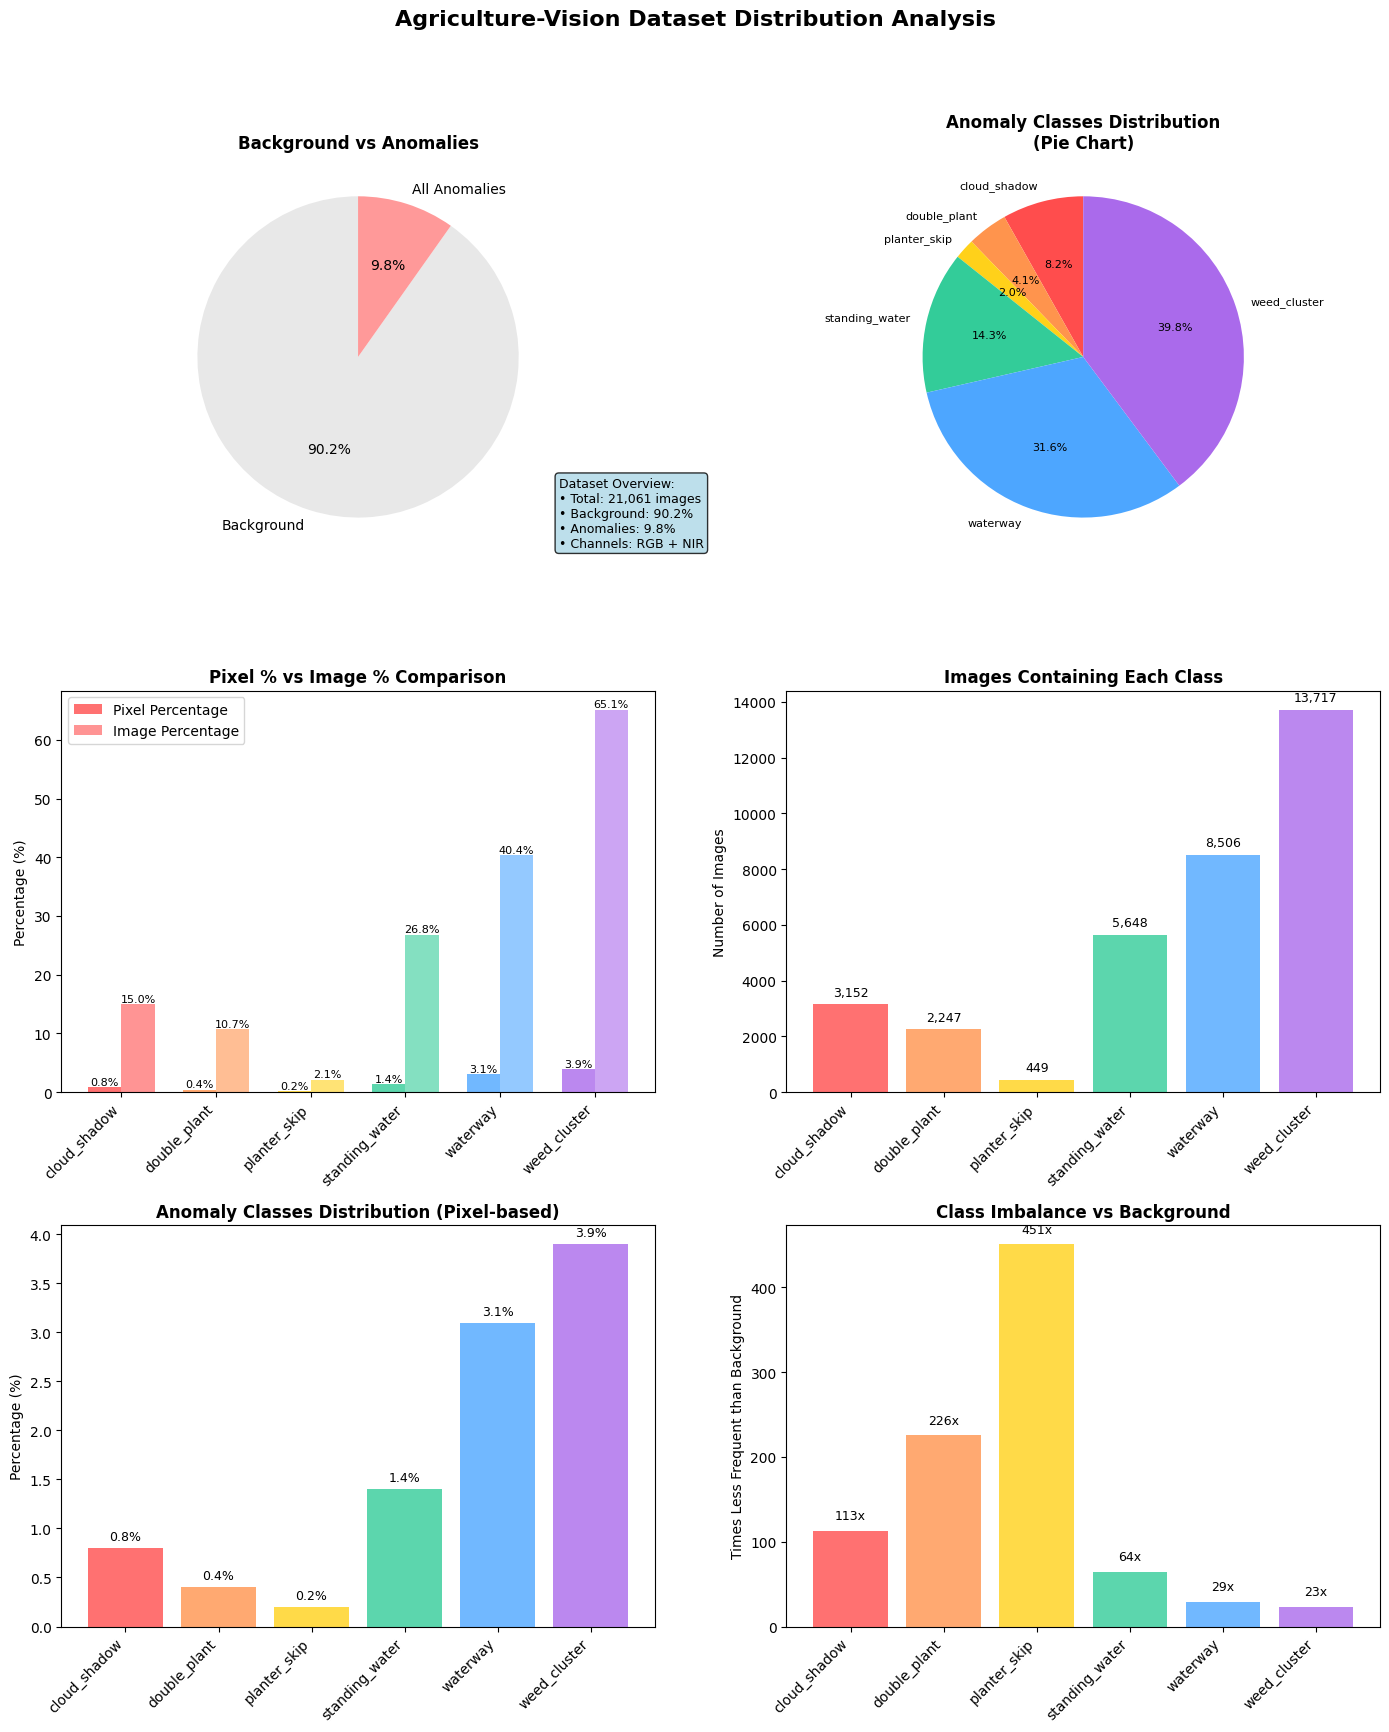

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 영어 폰트 설정
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_palette("pastel")

def create_dataset_distribution_plot():
    """
    Agriculture-Vision 데이터셋의 클래스 분포를 시각화합니다.
    실제 클래스 불균형을 반영하여 작성했습니다.
    """
    # Agriculture-Vision 데이터셋의 실제 클래스 분포 (픽셀 기준 %)
    # 배경 제외한 이상 클래스들
    anomaly_classes = ['cloud_shadow', 'double_plant', 'planter_skip', 
                      'standing_water', 'waterway', 'weed_cluster']
    
    # 실제 픽셀 분포 (배경 제외)
    anomaly_percentages = [0.8, 0.4, 0.2, 1.4, 3.1, 3.9]
    background_percentage = 90.2
    total_anomaly_percentage = sum(anomaly_percentages)
    
    # 실제 마스크 파일 수 (배경 제외)
    mask_file_counts = [3152, 2247, 449, 5648, 8506, 13717]
    
    # 클래스별 색상 정의 (기준 색상에서 20% 밝기 조정)
    anomaly_colors = [
        '#ff4d4d',  # 맑은 레드
        '#ff944d',  # 맑은 오렌지
        '#ffd11a',  # 맑은 옐로우
        '#33cc99',  # 맑은 그린
        '#4da6ff',  # 맑은 블루
        '#aa6aeb'   # 맑은 퍼플
    ]




    
    # 3x2 그리드로 서브플롯 배치
    fig = plt.figure(figsize=(14, 18))
    
    ax1 = plt.subplot(3, 2, 1)  # 배경 vs 이상 원형 그래프
    ax2 = plt.subplot(3, 2, 2)  # 이상 클래스별 픽셀 분포 막대
    ax3 = plt.subplot(3, 2, 3)  # 픽셀 수와 비율
    ax4 = plt.subplot(3, 2, 4)  # 이미지 수와 비율  
    ax5 = plt.subplot(3, 2, 5)  # 이상 클래스들 원형 그래프
    ax6 = plt.subplot(3, 2, 6)  # 불균형 정도
    
    fig.suptitle('Agriculture-Vision Dataset Distribution Analysis', 
                 fontsize=16, fontweight='bold')
    
    # 1. 배경 vs 이상 클래스 원형 그래프 (ax1 그대로 유지)
    background_vs_anomaly = [background_percentage, total_anomaly_percentage]
    bg_labels = ['Background', 'All Anomalies']
    bg_colors = ['#E8E8E8', '#FF9999']
    
    wedges, texts, autotexts = ax1.pie(background_vs_anomaly, labels=bg_labels,
                                       autopct='%1.1f%%', colors=bg_colors,
                                       startangle=90, textprops={'fontsize': 10})
    ax1.set_title('Background vs Anomalies', fontweight='bold')
    
    # 텍스트 박스 (왼쪽 아래 정렬)
    info_text = f"""Dataset Overview:
• Total: 21,061 images
• Background: {background_percentage}%
• Anomalies: {total_anomaly_percentage}%
• Channels: RGB + NIR"""
    
    ax1.text(1, 0.02, info_text, transform=ax1.transAxes, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
             verticalalignment='bottom', horizontalalignment='left')
    
    # 2. 이상 클래스별 픽셀 분포 막대
    bars2 = ax5.bar(range(len(anomaly_classes)), anomaly_percentages, 
                     color=anomaly_colors, alpha=0.8)
    ax5.set_xticks(range(len(anomaly_classes)))
    ax5.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax5.set_ylabel('Percentage (%)')
    ax5.set_title('Anomaly Classes Distribution (Pixel-based)', fontweight='bold')
    
    # 막대 위에 퍼센트 표시
    for bar, pct in zip(bars2, anomaly_percentages):
        ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct}%', ha='center', va='bottom', fontsize=9)
    
    # 3. 픽셀 비율(%)과 이미지 수 비교 - 두 개 막대 나란히
    x = np.arange(len(anomaly_classes))
    width = 0.35  # 막대 너비
    
    # 이미지 수 비율 계산
    image_percentages = [(count / 21061) * 100 for count in mask_file_counts]
    
    bars3_1 = ax3.bar(x - width/2, anomaly_percentages, width, 
                      label='Pixel Percentage', color=anomaly_colors, alpha=0.8)
    bars3_2 = ax3.bar(x + width/2, image_percentages, width,
                      label='Image Percentage', color=anomaly_colors, alpha=0.6)
    
    ax3.set_xticks(x)
    ax3.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax3.set_ylabel('Percentage (%)')
    ax3.set_title('Pixel % vs Image % Comparison', fontweight='bold')
    ax3.legend()
    
    # 막대 위에 값 표시
    for bar, pct in zip(bars3_1, anomaly_percentages):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct}%', ha='center', va='bottom', fontsize=8)
    
    for bar, pct in zip(bars3_2, image_percentages):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)
    
    # 4. 이미지 수 (원래 ax4를 ax4로 유지)
    bars4 = ax4.bar(range(len(anomaly_classes)), mask_file_counts, 
                     color=anomaly_colors, alpha=0.8)
    ax4.set_xticks(range(len(anomaly_classes)))
    ax4.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax4.set_ylabel('Number of Images')
    ax4.set_title('Images Containing Each Class', fontweight='bold')
    
    # 막대 위에 개수 표시
    for bar, count in zip(bars4, mask_file_counts):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{count:,}', ha='center', va='bottom', fontsize=9)
    
    # 2. 이상 클래스들만 원형 그래프
    wedges5, texts5, autotexts5 = ax2.pie(anomaly_percentages, labels=anomaly_classes,
                                    autopct='%1.1f%%', colors=anomaly_colors,
                                    startangle=90, textprops={'fontsize': 8})
    ax2.set_title('Anomaly Classes Distribution\n(Pie Chart)', fontweight='bold')
    
    # 6. 클래스 불균형 정도 (배경 대비)
    imbalance_ratios = [background_percentage / pct for pct in anomaly_percentages]
    
    bars6 = ax6.bar(range(len(anomaly_classes)), imbalance_ratios, 
                     color=anomaly_colors, alpha=0.8)
    ax6.set_xticks(range(len(anomaly_classes)))
    ax6.set_xticklabels(anomaly_classes, rotation=45, ha='right')
    ax6.set_ylabel('Times Less Frequent than Background')
    ax6.set_title('Class Imbalance vs Background', fontweight='bold')
    
    # 수치 표시
    for bar, ratio in zip(bars6, imbalance_ratios):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{ratio:.0f}x', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout(rect=[0, 0.02, 1, 0.95])  # 제목과 여백 확보
    
    return fig

# 실행
if __name__ == "__main__":
    fig = create_dataset_distribution_plot()
    plt.show()

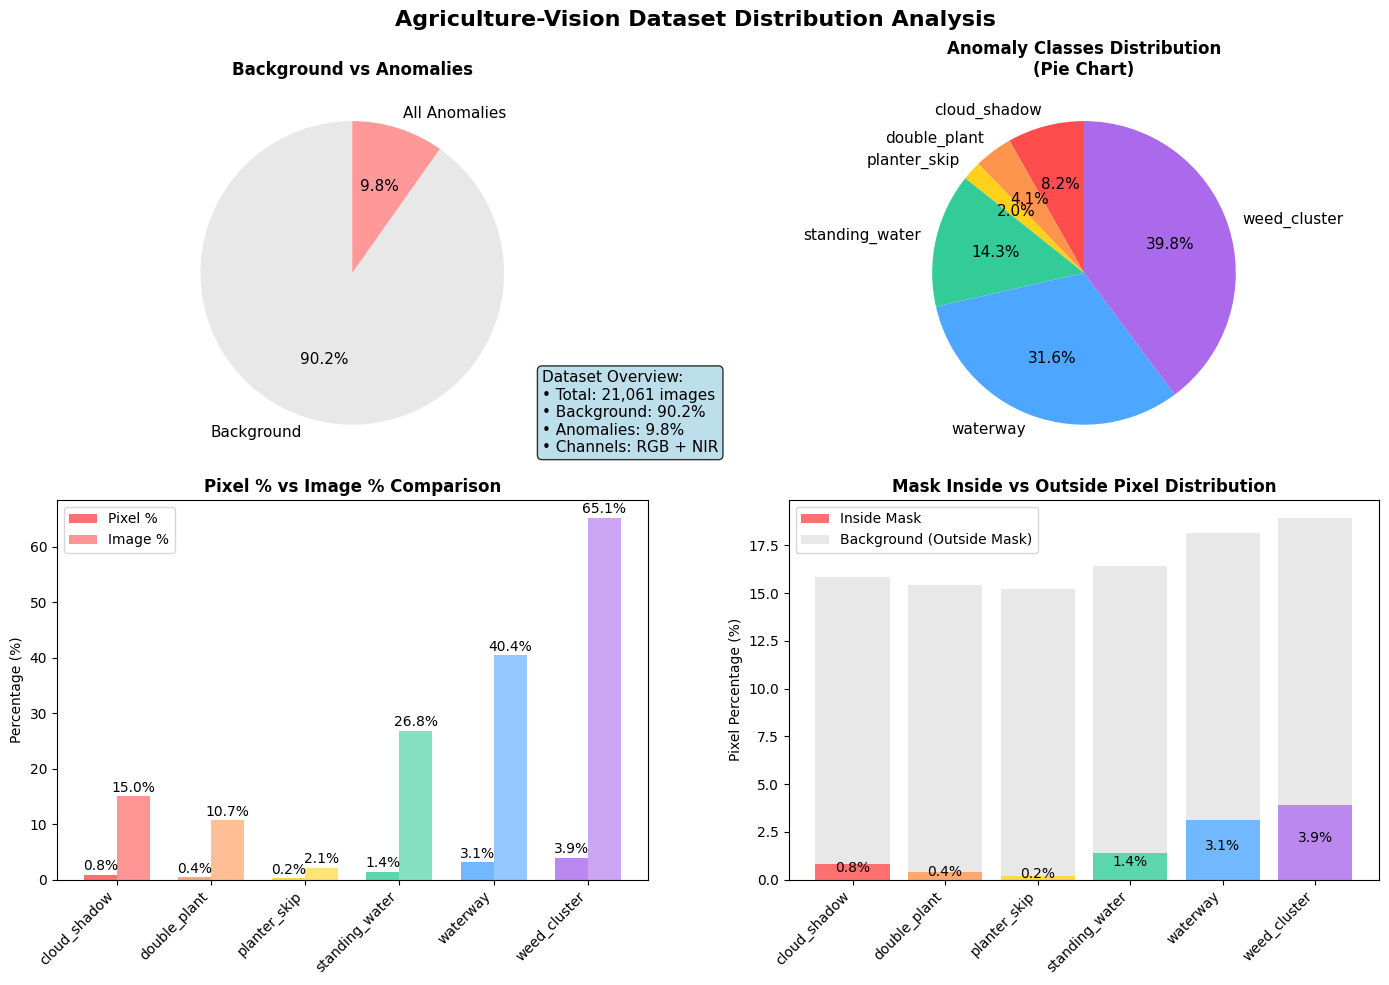


=== 마스크 분석 결과 ===
배경 픽셀 비율: 90.2%
전체 이상 픽셀 비율: 9.8%


In [96]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 폰트 설정
plt.rcParams['font.family'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({'font.size': 10})  # 20% 정도 증가
sns.set_palette("pastel")

# 클래스 정보
anomaly_classes = ['cloud_shadow', 'double_plant', 'planter_skip', 
                   'standing_water', 'waterway', 'weed_cluster']

anomaly_percentages = [0.8, 0.4, 0.2, 1.4, 3.1, 3.9]  # 픽셀 기준
background_percentage = 90.2
total_anomaly_percentage = sum(anomaly_percentages)

mask_file_counts = [3152, 2247, 449, 5648, 8506, 13717]  # 이미지 수

# 색상
anomaly_colors = [
    '#ff4d4d',  # 맑은 레드
    '#ff944d',  # 맑은 오렌지
    '#ffd11a',  # 맑은 옐로우
    '#33cc99',  # 맑은 그린
    '#4da6ff',  # 맑은 블루
    '#aa6aeb'   # 조정된 퍼플
]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Agriculture-Vision Dataset Distribution Analysis', fontsize=16, fontweight='bold')

ax1 = axs[0, 0]  # 배경 vs 이상
ax2 = axs[0, 1]  # 이상 클래스 원형
ax3 = axs[1, 0]  # 픽셀 vs 이미지 비율
ax4 = axs[1, 1]  # 마스크 내부 vs 외부 픽셀 분포

# 1. Background vs All Anomalies
ax1.pie([background_percentage, total_anomaly_percentage], 
        labels=['Background', 'All Anomalies'],
        autopct='%1.1f%%', colors=['#E8E8E8', '#FF9999'],
        startangle=90, textprops={'fontsize': 11})
ax1.set_title('Background vs Anomalies', fontweight='bold')

info_text = f"""Dataset Overview:
• Total: 21,061 images
• Background: {background_percentage}%
• Anomalies: {total_anomaly_percentage}%
• Channels: RGB + NIR"""
ax1.text(1, 0.02, info_text, transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8),
         verticalalignment='bottom', horizontalalignment='left')

# 2. Pie Chart of Anomalies
ax2.pie(anomaly_percentages, labels=anomaly_classes,
        autopct='%1.1f%%', colors=anomaly_colors,
        startangle=90, textprops={'fontsize': 11})
ax2.set_title('Anomaly Classes Distribution\n(Pie Chart)', fontweight='bold')

# 3. Pixel vs Image % Comparison
x = np.arange(len(anomaly_classes))
width = 0.35
image_percentages = [(count / 21061) * 100 for count in mask_file_counts]

bars_pixel = ax3.bar(x - width/2, anomaly_percentages, width,
                    label='Pixel %', color=anomaly_colors, alpha=0.8)
bars_image = ax3.bar(x + width/2, image_percentages, width,
                    label='Image %', color=anomaly_colors, alpha=0.6)

ax3.set_xticks(x)
ax3.set_xticklabels(anomaly_classes, rotation=45, ha='right')
ax3.set_ylabel('Percentage (%)')
ax3.set_title('Pixel % vs Image % Comparison', fontweight='bold')
ax3.legend()

for i, (pct, img_pct) in enumerate(zip(anomaly_percentages, image_percentages)):
    ax3.text(i - width/2, pct + 0.3, f'{pct}%', ha='center', va='bottom', fontsize=10)
    ax3.text(i + width/2, img_pct + 0.3, f'{img_pct:.1f}%', ha='center', va='bottom', fontsize=10)

# 4. Mask Inside vs Outside Pixel Distribution
total_anomaly_pixels = sum(anomaly_percentages)
remaining_background = 100 - total_anomaly_pixels

bars_mask_inside = ax4.bar(range(len(anomaly_classes)), anomaly_percentages,
                          color=anomaly_colors, alpha=0.8, label='Inside Mask')
bars_mask_outside = ax4.bar(range(len(anomaly_classes)), 
                           [remaining_background/len(anomaly_classes)] * len(anomaly_classes),
                           bottom=anomaly_percentages, color='lightgray', alpha=0.5,
                           label='Background (Outside Mask)')

ax4.set_xticks(range(len(anomaly_classes)))
ax4.set_xticklabels(anomaly_classes, rotation=45, ha='right')
ax4.set_ylabel('Pixel Percentage (%)')
ax4.set_title('Mask Inside vs Outside Pixel Distribution', fontweight='bold')
ax4.legend()

for bar, pct in zip(bars_mask_inside, anomaly_percentages):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
             f'{pct:.1f}%', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

# === 추가 분석 정보 출력 ===
print("\n=== 마스크 분석 결과 ===")
print(f"배경 픽셀 비율: {background_percentage:.1f}%")
print(f"전체 이상 픽셀 비율: {total_anomaly_percentage:.1f}%")
